### Data Analytics Task - A/B Testing and SQL

This notebook is an A/B testing analysis project that involves data cleaning, SQL operations, and statistical testing to compare the performance of two groups (Test and Control) based on their click-through rates (CTR) for a specific banner.

## Import Libraries


In [14]:
import pandas as pd
from scipy.stats import ttest_ind, chi2_contingency
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt

### Load Data

In [15]:
test_customer_keys = pd.read_csv('test_customer_keys.csv')
banner_views = pd.read_csv('banner_views.csv')
banner_clicks = pd.read_csv('banner_clicks.csv')

Three CSV files are loaded into Pandas DataFrames:

- test_customer_keys: Contains customer keys and their variant (Test or Control).
- banner_views: Records of banner views, including customer keys, banner names, and timestamps.
- banner_clicks: Records of banner clicks, including customer keys, banner names, and timestamps.

In [29]:
# Display first 5 rows of 'test customer keys' table
test_customer_keys.head()

,customer_key,customer_variant
0,a8cf21a461205975a97790c5aa05501a,Test
1,c05cca21bfaac87d226beb5b5a0f5689,Test
2,18e47b847aa6e50354a1ad3d60d4604d,Test
3,ecf77c568107ba2bda40360e0973efb0,Test
4,4fa8b68bb88c504a60d267225a591ae8,Test


In [17]:
# Display first 5 rows of 'test customer keys' table
banner_views.head()

,customer_key,banner_name,created_at,session_key
0,3b2f32d81bf642ca63a331c87ed5ce58,BFCbeans,2024-10-31 0:09:51,7912100be749f28e8c5866b9ea494009
1,b6928adde107030b9f57f2ca7feb4506,Burstbybreadfast,2024-10-31 0:40:34,f91cb69da56224cf5a57a603d0e31f54
2,3d148ae720c687b74b377a43db378373,Brekkienewdesign,2024-10-31 12:25:19,548d43fcad0676e2c97d442cbff25cca
3,c3dad81df9224d24c93d558241e2cdd7,Breakfastbasics,2024-10-31 3:37:55,fcd1569c9020c77a1445072d76a16ace
4,f4a585510b82bee129de358949f5a6c1,Halwani,2024-10-31 1:09:03,0b05512219f77454258932865f05d922


In [18]:
banner_clicks.head()

,customer_key,banner_name,created_at,session_key
0,19881d50dacce269056073ba0fcebb42,lunchbox2024,2024-10-31 2:13:08,cd697ca3b8b80afe7cd065edaacad522
1,8de3265c7a688f1d8cf80a3899ce5e6e,635a8n16277e3d0k0e69e89r,2024-10-31 9:02:00,215e721ec05d4c90233b8eae2e20859e
2,NaN,635a6cfa90c491000edf413e,2024-11-01 4:57:16,NaN
3,5bf181ccb427a03e38414bb53c8efc54,fd66FreeDelivery,2024-10-31 0:12:39,a744e6fe1ccef2cd2c2bd24437ed26eb
4,28db8e97291ba71752097fa71599f90b,Pril,2024-11-01 23:33:26,c5f40f12f34afe567d3a322961ca0c90


## Data Cleaning

In [19]:
# Check for missing values
print("Missing values in test_customer_keys:")
print(test_customer_keys.isnull().sum())

print("\nMissing values in banner_views:")
print(banner_views.isnull().sum())

print("\nMissing values in banner_clicks:")
print(banner_clicks.isnull().sum())

Missing values in test_customer_keys:
customer_key        0
customer_variant    0
dtype: int64

Missing values in banner_views:
customer_key     453
banner_name        0
created_at         0
session_key     4298
dtype: int64

Missing values in banner_clicks:
customer_key    1111
banner_name        0
created_at         0
session_key     2308
dtype: int64


- Missing values are found in banner views and banner clicks for customer key and session_key.

In [20]:
# Drop rows with missing values (if necessary)
test_customer_keys.dropna(inplace=True)
banner_views.dropna(inplace=True)
banner_clicks.dropna(inplace=True)

# Verify no missing values remain
print("Missing values after cleaning:")
print(test_customer_keys.isnull().sum())
print(banner_views.isnull().sum())
print(banner_clicks.isnull().sum())

Missing values after cleaning:
customer_key        0
customer_variant    0
dtype: int64
customer_key    0
banner_name     0
created_at      0
session_key     0
dtype: int64
customer_key    0
banner_name     0
created_at      0
session_key     0
dtype: int64


- Rows with missing values are dropped from all datasets.

## Create SQLite Database


In [21]:
# Create an in-memory SQLite database
engine = create_engine('sqlite:///:memory:')

# Load DataFrames into SQL tables
test_customer_keys.to_sql('test_customer_keys', engine, index=False)
banner_views.to_sql('banner_views', engine, index=False)
banner_clicks.to_sql('banner_clicks', engine, index=False)

13579

# Analysis

**Create Customer Groups View**

In [22]:
# Drop the view if it already exists
drop_query = text("DROP VIEW IF EXISTS customer_groups;")

# Create the view using sqlalchemy
create_query = text("""
CREATE VIEW customer_groups AS
SELECT c.customer_key,
       CASE WHEN t.customer_key IS NOT NULL THEN 'Test' ELSE 'Control' END AS customer_group
FROM (SELECT DISTINCT customer_key FROM banner_views UNION SELECT DISTINCT customer_key FROM banner_clicks) c
LEFT JOIN test_customer_keys t ON c.customer_key = t.customer_key;
""")

# Execute the queries
with engine.connect() as connection:
    connection.execute(drop_query)  # Drop the view if it exists
    connection.execute(create_query)  # Create the view
    connection.commit()  # save the transaction

In [23]:
# Check the first 5 rows of the view
customer_groups_sample = pd.read_sql("SELECT * FROM customer_groups;", engine)

customer_groups_sample

,customer_key,customer_group
0,0004c5e4353e6594b231eb346cf79d23,Control
1,000528824f9c6c395c47314ec75edfbe,Control
2,0007b33129fae8cfecbdd697cfdeb782,Test
3,0008400aabbd30af11e692bdac97a4c5,Control
4,001062a0e983a1d23c651bda00eee0e0,Control
...,...,...
15435,ffc9b947df7f09ea8d2e4e2aef2865a1,Control
15436,ffd4ef017c8d3399937c783bc3119715,Control
15437,ffe032f875593c10cad1e6886eae0c3c,Control
15438,ffe802b630ab228bdd90bfa6eb61b994,Control


- The view assigns each customer to either the "Test" or "Control" group based on whether their key exists in the test_customer_keys table.

**Calculate Impressions and Clicks**

In [ ]:
# Calculate impressions and clicks for banner
query = """
SELECT cg.customer_group,
       COUNT(bv.created_at) AS impressions,
       COUNT(bc.created_at) AS clicks
FROM customer_groups cg
LEFT JOIN banner_views bv ON cg.customer_key = bv.customer_key AND bv.banner_name = 'Juhayna60'
LEFT JOIN banner_clicks bc ON cg.customer_key = bc.customer_key AND bc.banner_name = 'Juhayna60'
GROUP BY cg.customer_group;
"""

# Execute the query
results = pd.read_sql(query, engine)
print("Impressions and Clicks:")
print(results)

Impressions and Clicks:
  customer_group  impressions  clicks
0        Control         5991    1006
1           Test         1070     201


- The query calculates the number of impressions (views) and clicks for the banner "Juhayna60" for both Test and Control groups.

In [25]:
# Calculate CTR (Click-Through Rate)
results['CTR'] = (results['clicks'] / results['impressions']) * 100
print("CTR Results:")
print(results)

CTR Results:
  customer_group  impressions  clicks        CTR
0        Control         5991    1006  16.791854
1           Test         1070     201  18.785047


- The results show that the Test group has a slightly higher CTR (18.79%) compared to the Control group (16.79%).

In [26]:
# Statistical test
contingency_table = [
    [results.loc[results['customer_group'] == 'Test', 'clicks'].values[0],
     results.loc[results['customer_group'] == 'Test', 'impressions'].values[0] - results.loc[results['customer_group'] == 'Test', 'clicks'].values[0]],
    [results.loc[results['customer_group'] == 'Control', 'clicks'].values[0],
     results.loc[results['customer_group'] == 'Control', 'impressions'].values[0] - results.loc[results['customer_group'] == 'Control', 'clicks'].values[0]]
]

# Perform Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"p-value: {p}")

p-value: 0.12084780876355133


- A chi-square test is performed to determine if the difference in CTR between the Test and Control groups is statistically significant.

- The p-value is 0.1208, which is greater than 0.05, indicating that the difference is not statistically significant.

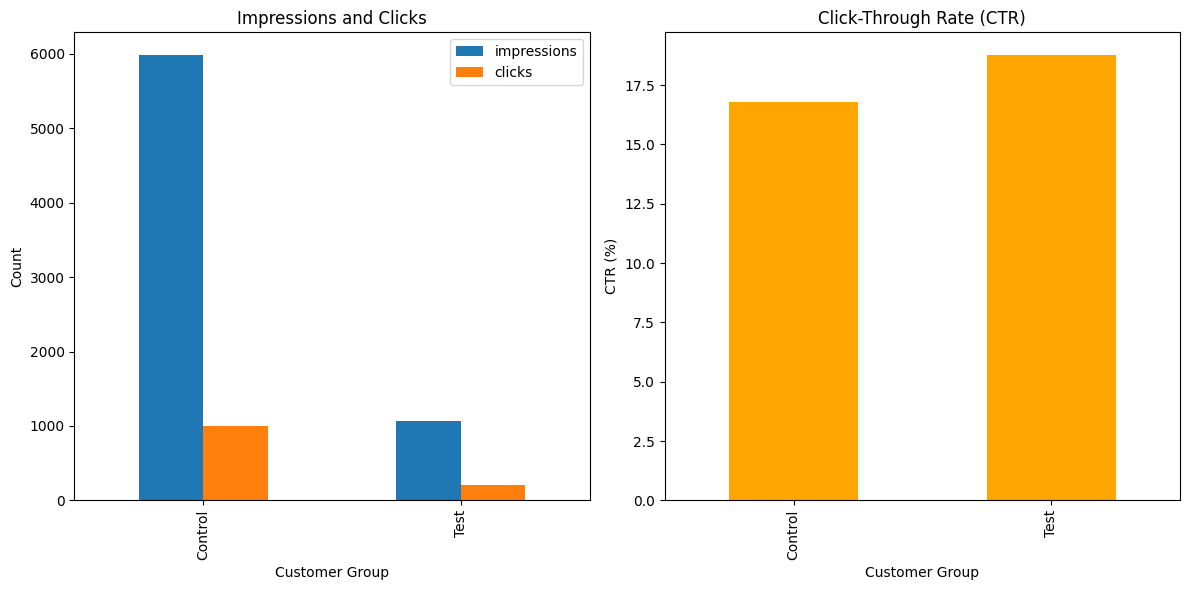

In [27]:
# Visualizing the results
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# Bar plot for impressions and clicks
results.set_index('customer_group')[['impressions', 'clicks']].plot(kind='bar', ax=ax[0])
ax[0].set_title('Impressions and Clicks')
ax[0].set_ylabel('Count')
ax[0].set_xlabel('Customer Group')

# CTR plot
results.set_index('customer_group')['CTR'].plot(kind='bar', ax=ax[1], color='orange')
ax[1].set_title('Click-Through Rate (CTR)')
ax[1].set_ylabel('CTR (%)')
ax[1].set_xlabel('Customer Group')

plt.tight_layout()
plt.show()


## Interpretation:


- The Test group has a slightly higher CTR than the Control group.

- However, the difference is not statistically significant (p-value > 0.05), meaning the observed difference could be due to random variation.

- Since the difference in CTR is not statistically significant, it is not advisable to implement the new banner weights.